# 05. Player values from box scores (M5)

M5 tried to value every player from his own box-score statistics, build each team's expected lineup before every game, and give the game model the difference between the lineup taking the field and the lineup its ratings remember. The method is in `context/ml-m5-method.md`; the results are in `context/ml.md` ("M5 build notes").

This notebook walks through it:

1. Credit assignment: turning plays into credit for one player.
2. Shrinkage: why a player with a few good games is pulled back toward replacement level.
3. Lineups: who plays, as a probability.
4. The roster-status leak, and how it was caught.
5. Why the game model didn't move.

Everything here uses CC BY data only. It reads the files `scripts/ml_m5.py` saved in `data/raw/ml/m5/` and the run records in `experiments/runs/`, so run that script first. Nothing here touches the 2020-2025 holdout.

In [1]:
import json
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nflelo").is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nflelo.ml import data as D, registry
from nflelo.ml.players import credit as cr, value as pv

plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
pd.set_option("display.width", 160)
INK, ACCENT, MUTED, BAD = "#1f2a44", "#2f6fdf", "#9aa3b2", "#d1495b"

M5 = D.ML_DIR / "m5"
runs = {r["name"]: r for r in registry.load_runs() if r["name"].startswith("m5_")}
values = pd.read_parquet(M5 / "values.parquet")
pg = pd.read_parquet(M5 / "player_games.parquet")
lineups = pd.read_parquet(M5 / "lineups_full.parquet")
probs = pd.read_parquet(M5 / "status_probs.parquet")
ladder = pd.read_parquet(M5 / "ladder_frame.parquet")
coefs = pd.read_parquet(M5 / "coefs.parquet")
names = D.load_players().drop_duplicates("gsis_id").set_index("gsis_id")["display_name"]
print(f"{len(pg):,} player-games, {len(values):,} weekly values, {len(runs)} M5 runs")

271,748 player-games, 1,006,394 weekly values, 9 M5 runs


## 1. Credit assignment

A play's EPA (expected points added) belongs to everyone on the field. Box scores only name a few of them: the passer, the target, the tackler, the sacker. M5 gives each named player a share of the play's EPA, by position, and measures it **per team play**, so that values add up across a lineup.

The hard part is separating a player from his teammates:

- A receiver's catches are partly his quarterback's work. So a receiver is credited with his EPA per target **minus his quarterback's average EPA per target to his other receivers**, times his share of targets.
- A running back is measured against the team's other backs behind the same line.
- Defenders get the EPA of the plays they are credited on (sacks, hits, tackles for loss, forced fumbles; for defensive backs, interceptions and passes defensed), with the sign flipped so that positive is good for the defense.
- Linemen have no individual stats at all.

The table shows how many player-games carry each kind of credit. Read the last column: defensive backs and running backs have almost nothing for a value to stand on.

In [2]:
comp = [c[2:] for c in pg.columns if c.startswith("c_")]
rows = []
for g, x in pg.groupby("group"):
    used = [c for c in comp if (x[f"a_{c}"] > 0).any() and (x[f"c_{c}"] != 0).any()]
    nz = (x[[f"c_{c}" for c in used]] != 0).any(axis=1).mean() if used else 0.0
    rows.append({"group": g, "player-games": len(x), "credit components": ", ".join(used),
                 "share of player-games with any credit": round(float(nz), 2)})
pd.DataFrame(rows).set_index("group")

,player-games,credit components,share of player-games with any credit
group,,,
CB,33643,"int, pd",0.42
DL,55628,"sack, qbhit, tfl, ff",0.40
K,11114,fg,0.87
LB,43829,"sack, qbhit, tfl, ff",0.34
QB,12218,db,0.99
RB,30686,"rush, rb_recv",1.00
S,28657,"int, pd",0.28
TE,17910,recv,1.00
WR,38063,recv,0.98


## 2. Shrinkage toward replacement level

A raw per-game average is noisy: a safety with one interception in two games looks like a star. M5 pulls every player toward **replacement level**, what a typical backup produces at his position:

value = (n x raw + k x replacement) / (n + k)

`n` is his recency-weighted games and `k` is the prior strength of his position group, tuned on 2001-2008 without using any game results (the target was each player's own credit in his next four games). The tuned `k` and how much of a player's next-four-games credit his value predicts ("skill", 1 = perfect, 0 = no better than assuming replacement level):

In [3]:
t = runs["m5_tune_players"]
k = pv.TUNED.kd
skill = {g: t["metrics"].get(f"skill_{g}") for g in k}
pd.DataFrame({"k (pseudo full games)": k, "skill": skill}).dropna().round(3).sort_values("skill", ascending=False)

,k (pseudo full games),skill
QB,4.0,0.297
K,16.0,0.134
DL,8.0,0.092
WR,16.0,0.086
LB,8.0,0.075
TE,16.0,0.048
CB,16.0,0.033
S,32.0,0.026
RB,16.0,0.022


Quarterbacks and kickers are measurable; everyone else barely is. A running back's credit next month is 2% predictable from his credit so far, a cornerback's 3%. That is the first warning sign for what follows: the values for most positions are mostly prior.

The chart shows the effect of shrinkage on 2019 receivers: players with little evidence (left) sit near zero, and only players with many games can move far from it. The table lists the top three players by box value in each group at the end of 2019 (linemen have no box value).

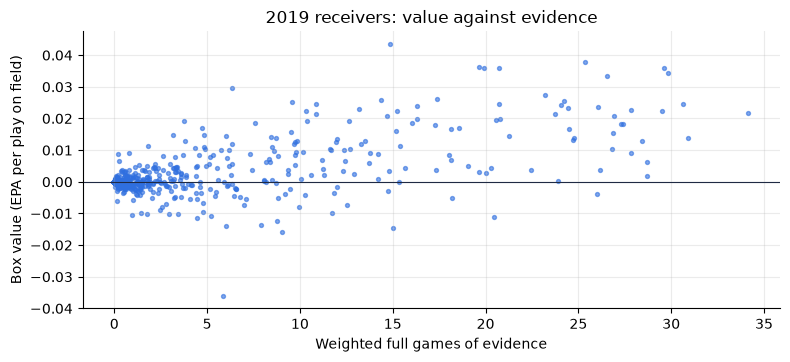

,name,n,v_box
group,,,
CB,Marcus Peters,22.653,0.022
CB,Stephon Gilmore,22.497,0.018
CB,Sean Murphy-Bunting,5.585,0.015
DL,Dee Ford,15.502,0.052
DL,Aaron Donald,31.112,0.038
DL,Danielle Hunter,28.974,0.037
K,Justin Tucker,36.889,0.007
K,Josh Lambo,30.447,0.007
K,Wil Lutz,32.989,0.007


In [4]:
last = values[(values["season"] == 2019) & (values["week"] == values.loc[values["season"] == 2019, "week"].max())]
wr = last[last["group"] == "WR"]
fig, ax = plt.subplots()
ax.scatter(wr["n"], wr["v_box"], s=8, color=ACCENT, alpha=0.6)
ax.axhline(0, color=INK, lw=0.8)
ax.set_xlabel("Weighted full games of evidence")
ax.set_ylabel("Box value (EPA per play on field)")
ax.set_title("2019 receivers: value against evidence")
plt.show()
boxed = last[last["n"].notna() & (last["group"] != "OL")]
top = boxed.assign(name=boxed["gsis_id"].map(names)).sort_values("v_box", ascending=False)
top.groupby("group").head(3)[["group", "name", "n", "v_box"]].sort_values(["group", "v_box"], ascending=[True, False]).round(3).set_index("group")

## 3. Who plays: a probability, not a yes or no

Before each game M5 builds the expected lineup in layers: the depth chart, then the weekly roster status (injured reserve and the like; only from 2016, see section 4), then the final injury report, then the game-day inactive list (from 2020). Each injury-report status maps to a probability of playing, estimated on 2009-2015 only:

In [5]:
probs.pivot(index="group", columns="status", values="p")[["out", "doubtful", "questionable", "practice", "none"]].round(2)

status,out,doubtful,questionable,practice,none
group,,,,,
CB,0.01,0.02,0.68,1.0,1.0
DL,0.00,0.03,0.78,1.0,1.0
K,0.00,0.02,0.76,1.0,1.0
LB,0.00,0.01,0.76,1.0,1.0
OL,0.00,0.02,0.77,1.0,1.0
QB,0.01,0.04,0.60,1.0,1.0
RB,0.00,0.01,0.87,1.0,1.0
S,0.00,0.01,0.73,1.0,1.0
TE,0.00,0.05,0.79,1.0,1.0


A player ruled Out or Doubtful almost never plays. A Questionable player plays 60% (QB) to 87% (RB) of the time, so a Questionable star counts as most of himself. The expected lineup value is the sum over listed players of (probability of playing) x (expected share of snaps) x (value).

Here is one real example, the most uncertain week for one team in 2019 (the team-week with the most listed starters below 90%):

In [6]:
l19 = lineups[(lineups["season"] == 2019) & (lineups["rank"] == 1) & (lineups["group"] != "K")]
worst = l19.assign(unsure=l19["p_play"] < 0.9).groupby(["week", "team"])["unsure"].sum().idxmax()
ex = l19[(l19["week"] == worst[0]) & (l19["team"] == worst[1]) & (l19["p_play"] < 1)].copy()
ex["name"] = ex["gsis_id"].map(names)
print(f"2019 week {worst[0]}, {worst[1]}: rank-1 starters not certain to play")
ex[["name", "group", "status", "roster_status", "p_play", "share_exp"]].round(2).sort_values("p_play").reset_index(drop=True)

2019 week 10, NYJ: rank-1 starters not certain to play


,name,group,status,roster_status,p_play,share_exp
0,Neville Hewitt,LB,doubtful,INA,0.00,0.89
1,Darryl Roberts,CB,doubtful,INA,0.00,0.62
2,Ryan Kalil,OL,doubtful,INA,0.00,1.00
3,C.J. Mosley,LB,out,INA,0.00,0.96
4,Jordan Jenkins,LB,questionable,ACT,0.76,0.71
5,Kelvin Beachum,OL,questionable,ACT,0.77,1.00
6,Brian Winters,OL,questionable,ACT,0.77,1.00
7,Henry Anderson,DL,questionable,ACT,0.78,0.80
8,Steve McLendon,DL,questionable,ACT,0.78,0.71
9,Chris Herndon,TE,questionable,ACT,0.79,0.64


## 4. The roster-status leak

The first ladder run looked like a success: a count of "rank-1 starters on reserve" beat A4s by 0.0027 Brier. Two things gave it away:

- It had **zero** correlation with the market's view (0.007). Real injury news moves betting lines, so a real signal should correlate with them.
- The gain was too big. Injury news for non-QB players is worth a fraction of what the starting QB is worth, and the whole QB term earned about 0.0027.

The cause was in the data. The nflverse weekly rosters mark players as reserve (RES), but before 2016 that status is effectively the **season-end** status, copied onto every week. A player who went on injured reserve in December shows as RES in September too. That is future information.

The check M5 now runs (`lineup.roster_status_seasons`): among player-weeks marked RES or cut, how many were credited on a play for that same week? A true weekly status almost never plays.

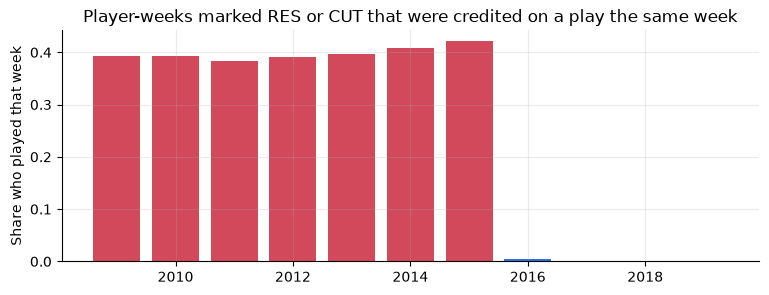

season,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
share played,0.392,0.392,0.384,0.392,0.397,0.408,0.421,0.004,0.0,0.0,0.0


In [7]:
seasons = range(2009, 2020)
ros = D.load_rosters_weekly(seasons)
ros = ros[(ros["game_type"] == "REG") & ros["status"].isin(["RES", "CUT"])][["season", "week", "gsis_id"]]
played = pg[["season", "week", "gsis_id"]].drop_duplicates().assign(played=1.0)
x = ros.merge(played, on=["season", "week", "gsis_id"], how="left").fillna({"played": 0.0})
rate = x.groupby("season")["played"].mean()
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(rate.index, rate.to_numpy(), color=[BAD if v > 0.02 else ACCENT for v in rate.to_numpy()])
ax.set_ylabel("Share who played that week")
ax.set_title("Player-weeks marked RES or CUT that were credited on a play the same week")
plt.show()
rate.round(3).to_frame("share played").T

Before 2016, a third or more of "reserve" player-weeks actually played (this check sees only credited plays, so the true share is higher). From 2016 the status is week-accurate. M5 now uses the roster layer only in seasons that pass the check. After the fix the same starters-out count had no gain (-0.0001, CI [-0.0009, +0.0007]) and correlated with the market (-0.15) the way real injury news should.

The lesson generalizes: **a feature that beats the model but ignores what the market knows is more likely a leak than a discovery.**

## 5. Why the game model didn't move

The ladder, every step scored on the same 2,047 games (REG 2012-2019 with moneylines), against A4s (B0):

In [8]:
order = ["m5_B0", "m5_B0r", "m5_B1", "m5_B2", "m5_B3", "m5_B4", "m5_B5", "m5_B3f"]
rows = []
for n in order:
    r = runs[n]
    c = r["comparisons"]["vs_B0_brier"]
    rows.append({"step": n[3:], "Brier": r["metrics"]["brier"],
                 "vs A4s [95% CI]": "" if n == "m5_B0" else f"{c['diff']:+.4f} [{c['ci_low']:+.4f}, {c['ci_high']:+.4f}]",
                 "chosen": "yes" if r["one_se"]["chosen"] else "", "note": r["notes"].split(". ")[0].rstrip(".")})
pd.DataFrame(rows).set_index("step")

,Brier,vs A4s [95% CI],chosen,note
step,,,,
B0,0.214658,,yes,Reference: A4s as in M3 (trained 2001..S-1)
B0r,0.215022,"+0.0004 [-0.0000, +0.0007]",,Diagnostic: A4s features trained 2009..S-1
B1,0.214902,"+0.0002 [-0.0006, +0.0011]",,lineup_delta_diff from box-score values
B2,0.215048,"+0.0004 [-0.0004, +0.0012]",,lineup_delta_diff from with/without values
B3,0.215420,"+0.0008 [-0.0004, +0.0019]",,B2 + preseason roster change (fading)
B4,0.215411,"+0.0008 [-0.0004, +0.0020]",,B3 with offense/defense split
B5,0.215471,"+0.0008 [-0.0003, +0.0020]",,B3 with 0/1 play probabilities
B3f,0.215460,"+0.0008 [-0.0004, +0.0019]",,B3 without inactives (Friday-only; M5-D2)


Every interval includes zero, and the one-SE rule keeps plain A4s. The lineup terms are not noise, though. Their coefficients are positive in every season's refit, and they agree with the market:

In [9]:
c = coefs[coefs["step"].isin(["B1", "B2"])]
feat = {"B1": "lineup_delta_diff__box_full", "B2": "lineup_delta_diff__ww_full"}
ev = ladder[ladder["eval"]]
mkt = runs["m5_B0"]
summary = {}
for s, f in feat.items():
    cc = c[c["step"] == s][f]
    summary[s] = {"coefficient range over refits": f"{cc.min():+.2f} to {cc.max():+.2f}",
                  "feature SD": round(float(ev[f].std()), 4),
                  "effect of 1 SD on the log-odds": round(float(cc.iloc[-1] * ev[f].std()), 3),
                  "bootstrap SE of the Brier difference": round(runs[f"m5_{s}"]["comparisons"]["vs_B0_brier"]["boot_se"], 5)}
pd.DataFrame(summary).T

,coefficient range over refits,feature SD,effect of 1 SD on the log-odds,bootstrap SE of the Brier difference
B1,+3.33 to +5.11,0.023,0.095,0.00044
B2,+2.41 to +4.23,0.0279,0.071,0.00041


So why no gain? Size and power:

- **The effect is small.** One standard deviation of the lineup delta moves the home team's log-odds by about 0.07 to 0.10, roughly two percentage points of win probability near a coin flip. Most games have no lineup news at all.
- **The test can't see something that small.** The standard error of a Brier difference on 2,047 games is about 0.0004 (last column). A real gain of 0.0002 is invisible.
- **Box-score values are mostly prior.** Section 2 showed that box scores barely predict their own future for most positions, so the values the lineup sums are weak.
- **The market already prices injuries.** A4s doesn't use the market, but the outcomes it is scored on already reflect what the teams knew.

That last point about weak values is what M5b addresses: it rates players from who was on the field for every snap (participation data, CC BY-SA), instead of from box-score credit. See `06_player_ratings.ipynb`.